In [1]:
import importlib
from pathlib import Path
import json
import yaml
import torch
import numpy as np
import sklearn
import matplotlib.pyplot as plt

import project_main.tokens as project_tokens
import project_main.data as project_data
import project_main.model as project_model
import project_main.checkpoints as project_checkpoints

importlib.invalidate_caches()
importlib.reload(project_tokens)
importlib.reload(project_checkpoints)


<module 'project_main.checkpoints' from '/Users/rohanbuluswar/Desktop/Line Break Project/src/project_main/checkpoints.py'>

In [2]:
RUN_DIR = Path("../results/line_breaks_results")
CHECKPOINT_PATH = RUN_DIR / "checkpoints" / "final.pt"
with open(RUN_DIR / "config.json", "r") as f:
    cfg = json.load(f)

device = "cpu"
vocab = project_tokens.build_vocab(cfg['task'])
model = project_model.build_model(cfg=cfg, device=device)

checkpoint = project_checkpoints.load_checkpoint(path=CHECKPOINT_PATH, model=model,map_location=device)
model.eval()

checkpoint['step']

Building vocab...
('BOS', 'NEWLINE')


10000

In [3]:
from sklearn.decomposition import PCA
W_E = model.W_E.detach().cpu().numpy()

regular_tokens_embeddings = W_E[2:,]
print(regular_tokens_embeddings.shape)


pca = PCA(n_components=2)
token_coords = pca.fit_transform(regular_tokens_embeddings)
print(pca.explained_variance_ratio_)


(80, 128)
[0.15455984 0.04835687]


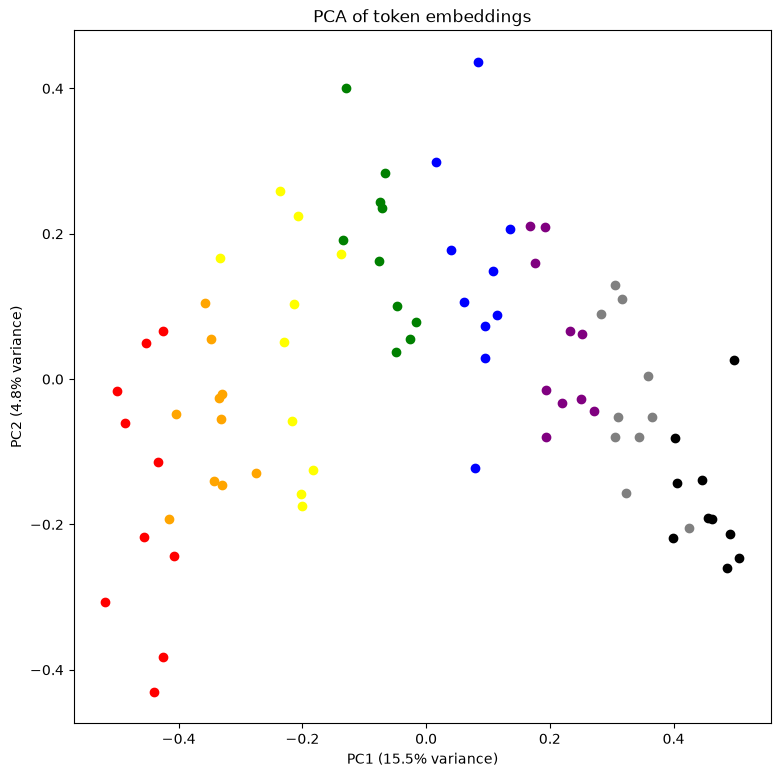

In [4]:
## 2-dim PCA of all Token Embeddings

token_ids = range(80)
color_coding = {1: 'red', 2: 'orange', 3:'yellow', 4: 'green', 5: 'blue', 6: 'purple', 7:'gray', 8:'black'}

plt.figure(figsize=(9, 9))

for token_id in token_ids:
    x, y = token_coords[token_id]
    token_length = project_data.extract_character_count(vocab.decode_token(token_id+2))
    plt.scatter(x, y, color=color_coding[token_length])
    # plt.annotate(project_data.extract_character_count(vocab.decode_token(token_id+4)), (x, y))

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)"
)
plt.title("PCA of token embeddings")
plt.show()

[30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


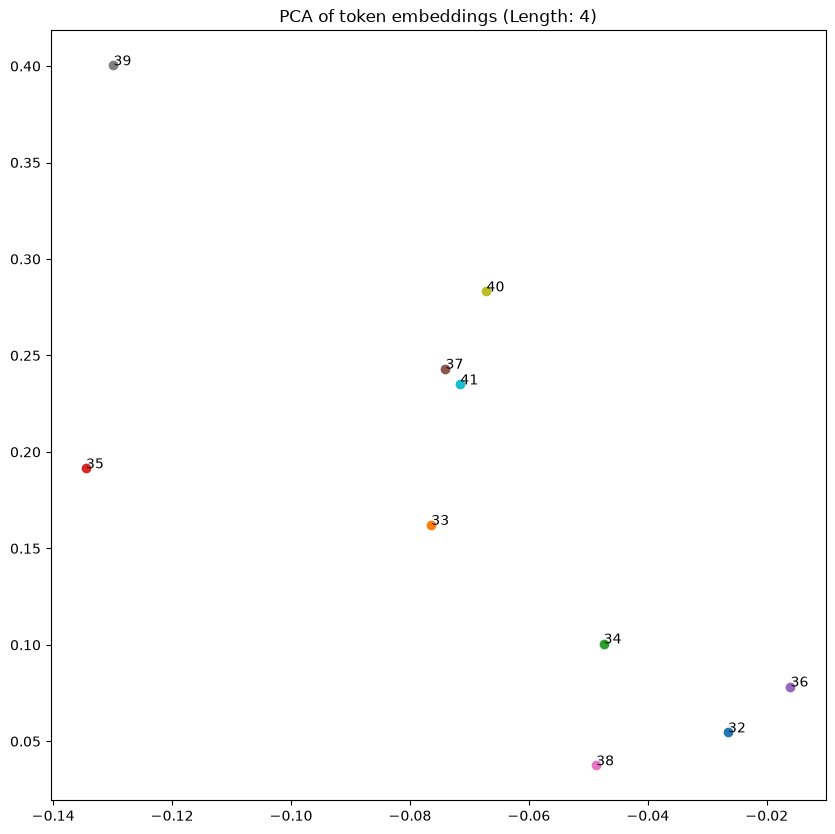

In [5]:
#2-dim PCA of Tokens Grouped by Token Length
target_length = 4
freeze_scale = False

token_ids_of_length = [token_id - 2 for token_id in range(2, 82) if project_data.extract_character_count(vocab.decode_token(token_id)) == target_length]
print((token_ids_of_length))
plt.figure(figsize=(10, 10))

for token_id in token_ids_of_length:
    x, y = token_coords[token_id]
    plt.scatter(x, y)
    plt.annotate(2+token_id, (x, y))

plt.title(f"PCA of token embeddings (Length: {target_length})")
if freeze_scale:
    plt.xlim(-1,1)
    plt.ylim(-0.3,1.5)
plt.show()


(8, 2)


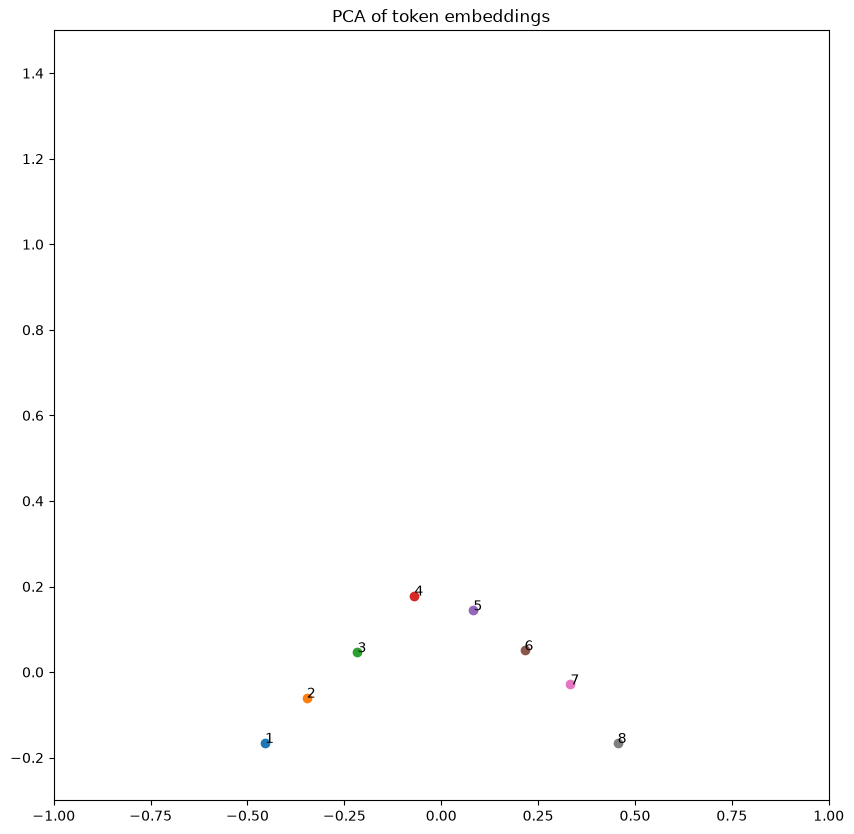

In [6]:
##2-dim PCA of all Token Embeddings averaged by Token Length:
avg_embeddings_by_length = []

for length in range(1, 9):
    token_ids_of_length = [token_id - 2 for token_id in range(2, 82) if project_data.extract_character_count(vocab.decode_token(token_id)) == length]
    avg_embedding = regular_tokens_embeddings[token_ids_of_length].mean(axis=0)
    avg_embeddings_by_length.append(avg_embedding)



avg_embedding_coords = pca.transform(np.column_stack(avg_embeddings_by_length).T)
print(avg_embedding_coords.shape)


plt.figure(figsize=(10, 10))
for length in range(1,9):
    x, y = avg_embedding_coords[length-1]
    plt.scatter(x, y)
    plt.annotate(repr(length), (x, y))

plt.title(f"PCA of token embeddings")
plt.xlim(-1,1)
plt.ylim(-0.3,1.5)
plt.show()



[0.15455984 0.04835687 0.04393879]


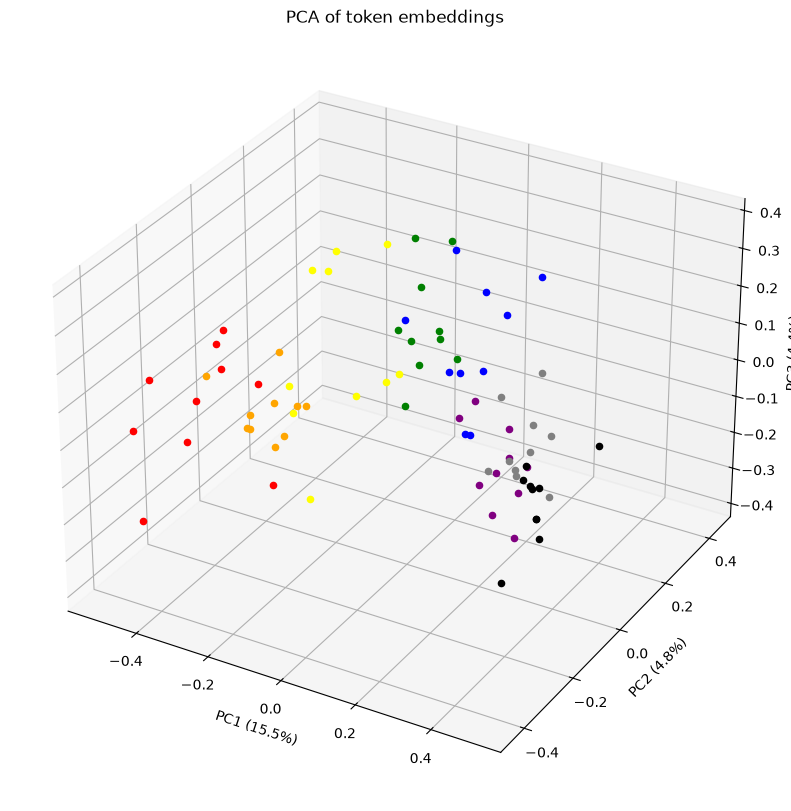

In [7]:
# 3-D PCA of All Tokens
three_dim_pca = PCA(n_components=3)
three_dim_token_coords = three_dim_pca.fit_transform(regular_tokens_embeddings)
print(three_dim_pca.explained_variance_ratio_)

token_ids = range(80)
color_coding = {1: 'red', 2: 'orange', 3:'yellow', 4: 'green', 5: 'blue', 6: 'purple', 7:'gray', 8:'black'}

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

for token_id in token_ids:
    x, y, z = three_dim_token_coords[token_id]
    token_length = project_data.extract_character_count(vocab.decode_token(2+token_id))
    ax.scatter(x, y, z, color=color_coding[token_length])
    

ax.set_xlabel(f"PC1 ({three_dim_pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({three_dim_pca.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"PC3 ({three_dim_pca.explained_variance_ratio_[2]:.1%})")
ax.set_title("PCA of token embeddings")
plt.title("PCA of token embeddings")
plt.show()

(8, 3)


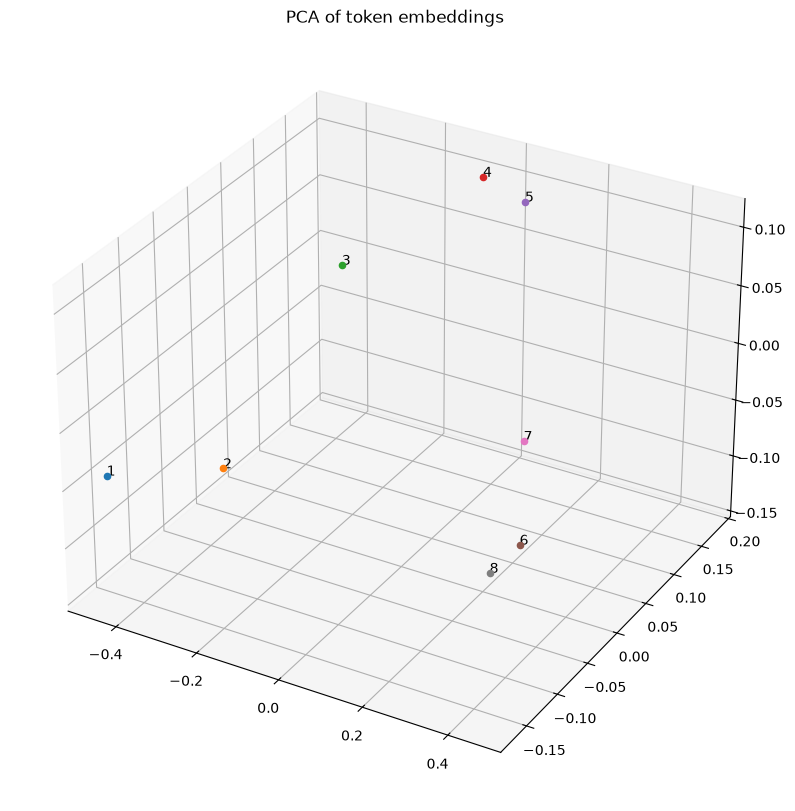

In [8]:
#3-D PCA of Tokens by Avg Length
avg_embeddings_by_length = []

for length in range(1, 9):
    token_ids_of_length = [token_id - 2 for token_id in range(2, 82) if project_data.extract_character_count(vocab.decode_token(token_id)) == length]
    avg_embedding = regular_tokens_embeddings[token_ids_of_length].mean(axis=0)
    avg_embeddings_by_length.append(avg_embedding)



avg_embedding_coords = three_dim_pca.transform(np.column_stack(avg_embeddings_by_length).T)
print(avg_embedding_coords.shape)


fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

for length in range(1,9):
    x, y, z = avg_embedding_coords[length-1]
    ax.scatter(x, y, z,)
    ax.text(x, y, z, repr(length))


plt.title(f"PCA of token embeddings")
plt.show()
